In [21]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [22]:
df = pd.read_csv("./assets/insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


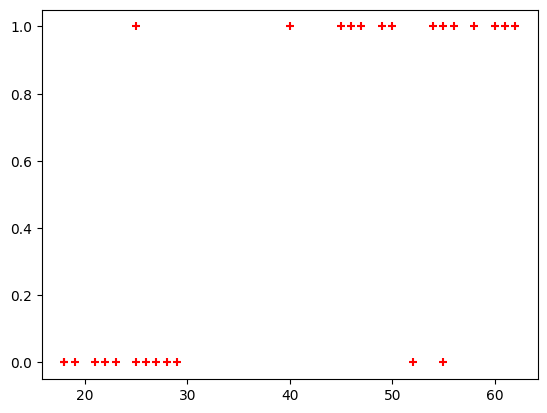

In [23]:
plt.scatter(df.age, df.bought_insurance, marker="+", color="red")

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["age"]], df.bought_insurance, train_size=0.8, random_state=10
)

In [26]:
X_test

,age
7,60
5,56
18,19
21,26
11,28
1,25


In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [28]:
model.fit(X_train, y_train)

LogisticRegression()

In [29]:
X_test

,age
7,60
5,56
18,19
21,26
11,28
1,25


In [30]:
y_predicted = model.predict(X_test)

In [31]:
model.predict_proba(X_test)

array([[0.07149837, 0.92850163],
       [0.10786034, 0.89213966],
       [0.88695424, 0.11304576],
       [0.78083769, 0.21916231],
       [0.73981335, 0.26018665],
       [0.79952571, 0.20047429]])

In [32]:
model.score(X_test, y_test)

1.0

In [33]:
y_predicted

array([1, 1, 0, 0, 0, 0])

In [34]:
X_test

,age
7,60
5,56
18,19
21,26
11,28
1,25


In [35]:
model.coef_, model.intercept_

(array([[0.112778]]), array([-4.20278276]))

Lets defined sigmoid function now and do the math with hand

In [36]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [37]:
def prediction_function(age):
    z = 0.042 * age - 1.53  # 0.04150133 ~ 0.042 and -1.52726963 ~ -1.53
    y = sigmoid(z)
    return y

In [38]:
age = 35
prediction_function(age)

0.4850044983805899

In [39]:
age = 43
prediction_function(age)

0.568565299077705

Exercise

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [41]:
df = pd.read_csv("assets/HR_comma_sep.csv")
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [42]:
left = df[df.left == 1]
left.shape

(3571, 10)

In [43]:
retained = df[df.left == 0]
retained.shape

(11428, 10)

In [44]:
df.groupby("left").mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


<Axes: xlabel='salary'>

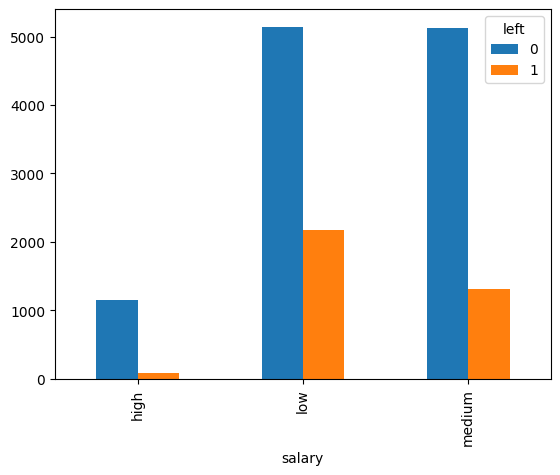

In [45]:
pd.crosstab(df.salary, df.left).plot(kind="bar")

<Axes: xlabel='Department'>

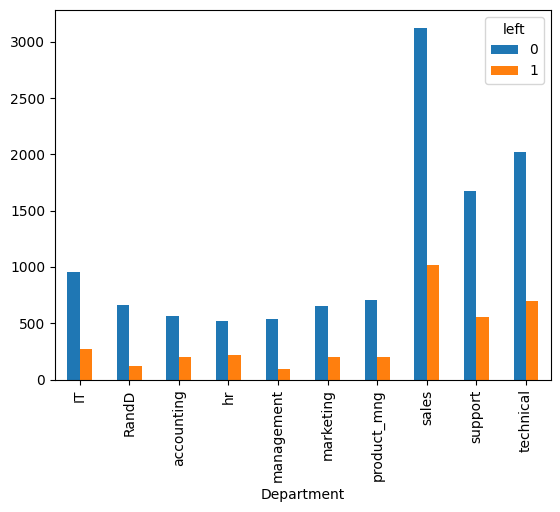

In [46]:
pd.crosstab(df.Department, df.left).plot(kind="bar")

In [47]:
df2 = pd.get_dummies(df, columns=['salary'], drop_first=False)
df2 = df2.drop('Department', axis='columns')

df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,True,False


In [48]:
df2= df2.astype(int)
df2.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_high,salary_low,salary_medium
0,0,0,2,157,3,0,1,0,0,1,0
1,0,0,5,262,6,0,1,0,0,0,1
2,0,0,7,272,4,0,1,0,0,0,1
3,0,0,5,223,5,0,1,0,0,1,0
4,0,0,2,159,3,0,1,0,0,1,0


In [49]:
X_train, X_test, y_train, y_test = train_test_split(df2[['satisfaction_level', 'Work_accident', 'promotion_last_5years', 'salary_high','salary_low', 'salary_medium']], df['left'], test_size=0.2)

In [50]:
# X_test.head()
y_test.head()

1369     1
6955     0
6106     0
8497     0
11969    0
Name: left, dtype: int64

In [51]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [52]:
model.score(X_test, y_test)

0.7566666666666667

In [53]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])